# 0_1. Odległości, macierze sąsiedztwa i graf kNN — ręcznie

Ten notebook jest fundamentem dla **KNN**, **DBSCAN**, **UMAP** i metod grafowych.

Wszystkie te metody zaczynają od tego samego pytania:

> które punkty są blisko siebie?

Będziemy używać sześciu punktów `A, B, C, D, E, F`, żeby ręcznie zobaczyć:

1. jak powstaje **macierz odległości**,
2. jak z odległości zrobić **macierz sąsiedztwa**,
3. czym różni się graf promienia $\varepsilon$ od grafu $k$NN,
4. dlaczego graf $k$NN może być **kierunkowy**,
5. czym różni się symetryzacja **union/OR** od **mutual/AND**,
6. dlaczego zbyt duże $k$ może sztucznie połączyć oddzielne grupy.


## Jak prowadzić ten notebook?

Najpierw nie mówimy jeszcze o pełnych algorytmach. Zaczynamy od jednego pytania:

> Mamy punkty. Jak komputer ma zdecydować, które punkty są do siebie podobne?

Cała ścieżka jest taka:

```text
punkty → odległości → sąsiedztwo → graf → algorytmy
```

Dopiero później pokazujemy, że z tej samej idei korzystają **KNN**, **DBSCAN**, **UMAP**, **t-SNE**, spectral clustering i metody grafowe.


## Do jakiej rodziny należy metoda?

PCA:
→ metody projekcyjne

t-SNE:
→ metody podobieństw

UMAP:
→ metody grafowe

KNN:
→ metody sąsiedztwa

DBSCAN:
→ metody gęstościowe

KMeans:
→ metody centroidowe

LDA:
→ metody dyskryminacyjne

SVM:
→ metody maksymalnego marginesu

## 0. Importy i ustawienia

Ta komórka nie jest jeszcze „algorytmem”. Ona tylko ładuje biblioteki i ustawia czytelniejsze wyświetlanie liczb oraz wykresów.

Ważne: tabele pokazujemy jako zwykłe `DataFrame`, bez niestabilnych warstw stylowania. Dzięki temu wartości nie powinny renderować się jako dziwne obiekty HTML.


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.precision', 3)

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True


## 0.1. Funkcje pomocnicze: odległości i macierze

Te funkcje będą używane w całym notebooku.

Najważniejsza jest `pairwise_distances(X)`, która liczy macierz:

$$
D_{ij}=d(x_i,x_j).
$$

Dla punktów dwuwymiarowych będzie to odległość euklidesowa:

$$
d(x_i,x_j)=\sqrt{(x_{i1}-x_{j1})^2+(x_{i2}-x_{j2})^2}.
$$


In [33]:
def pairwise_distances(X):
    """Liczy macierz odległości euklidesowych między wszystkimi parami punktów."""
    X = np.asarray(X, dtype=float)
    diff = X[:, None, :] - X[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def format_matrix_for_display(M, labels, number_format='.2f'):
    """Zwraca zwykły DataFrame bez Stylera i bez pustych wartości.

    number_format='.2f' — dobre dla odległości.
    number_format='.0f' — dobre dla macierzy 0/1.
    """
    M = np.asarray(M)
    formatted = []
    for i in range(M.shape[0]):
        row = []
        for j in range(M.shape[1]):
            value = M[i, j]
            if number_format == '.0f':
                row.append(f'{float(value):.0f}')
            elif number_format == '.1f':
                row.append(f'{float(value):.1f}')
            elif number_format == '.3f':
                row.append(f'{float(value):.3f}')
            else:
                row.append(f'{float(value):.2f}')
        formatted.append(row)
    return pd.DataFrame(formatted, index=labels, columns=labels)


def show_matrix(M, labels, title, number_format='.2f', cmap='viridis',
                vmin=None, vmax=None, figsize=(4.6, 4.0)):
    """Pokazuje macierz jako tabelę oraz heatmapę."""
    M = np.asarray(M)

    display(Markdown(f'**{title}**'))
    display(format_matrix_for_display(M, labels, number_format=number_format))

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_title(title)

    for i in range(len(labels)):
        for j in range(len(labels)):
            value = float(M[i, j])
            if number_format == '.0f':
                txt = f'{value:.0f}'
            elif number_format == '.1f':
                txt = f'{value:.1f}'
            elif number_format == '.3f':
                txt = f'{value:.3f}'
            else:
                txt = f'{value:.2f}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()


## Skąd bierze się trzeci wymiar w `pairwise_distances`?

Punkty zapisujemy jako macierz

$$
X \in \mathbb{R}^{n\times d},
$$

gdzie:

- $n$ — liczba punktów,
- $d$ — liczba współrzędnych.

Po wykonaniu:

```python
X[:, None, :] - X[None, :, :]
```

otrzymujemy tablicę

$$
\mathrm{diff}\in\mathbb{R}^{n\times n\times d}.
$$

Interpretacja indeksów jest następująca:

$$
\mathrm{diff}[i,j,:] = x_i - x_j.
$$

Czyli:

- pierwszy indeks $i$ wybiera punkt z lewej strony odejmowania,
- drugi indeks $j$ wybiera punkt z prawej strony odejmowania,
- trzeci indeks przechowuje różnice współrzędnych, np. $(dx,dy)$.

Najłatwiej zobaczyć to jako tabelę wszystkich par punktów: wiersze to punkt $i$, kolumny to punkt $j$.

In [34]:
X_demo = np.array([
    [0, 0],   # A
    [1, 0],   # B
    [1, 1]    # C
], dtype=float)

labels_demo = np.array(["A", "B", "C"])

def vec_txt(v):
    """Ładny zapis wektora 2D bez zbędnych miejsc po przecinku."""
    return f"({v[0]:.0f}, {v[1]:.0f})"

display(Markdown("### 1. Punkty jako tabela"))

df_points = pd.DataFrame(X_demo, index=labels_demo, columns=["x", "y"]).astype(int)
display(df_points)

display(Markdown("### 2. Co robią `X[:, None, :]` oraz `X[None, :, :]`?"))

left = X_demo[:, None, :]
right = X_demo[None, :, :]

shape_df = pd.DataFrame({
    "obiekt": ["X", "X[:, None, :]", "X[None, :, :]"],
    "shape": [str(X_demo.shape), str(left.shape), str(right.shape)],
    "intuicja": [
        "lista punktów",
        "kolumna punktów: A, B, C",
        "wiersz punktów: A, B, C"
    ]
})
display(shape_df)

display(Markdown("### 3. Broadcasting: NumPy rozszerza kolumnę i wiersz do siatki par"))

left_symbols = pd.DataFrame(
    [[labels_demo[i] for j in range(len(labels_demo))] for i in range(len(labels_demo))],
    index=labels_demo,
    columns=labels_demo
)

right_symbols = pd.DataFrame(
    [[labels_demo[j] for j in range(len(labels_demo))] for i in range(len(labels_demo))],
    index=labels_demo,
    columns=labels_demo
)

display(Markdown("**Lewa strona odejmowania:** każdy wiersz powtarza punkt $i$"))
display(left_symbols)

display(Markdown("**Prawa strona odejmowania:** każda kolumna powtarza punkt $j$"))
display(right_symbols)

display(Markdown("### 4. Odejmowanie po broadcastingu"))

symbolic_subtraction = pd.DataFrame(
    [[f"{labels_demo[i]} - {labels_demo[j]}" for j in range(len(labels_demo))]
     for i in range(len(labels_demo))],
    index=labels_demo,
    columns=labels_demo
)
display(symbolic_subtraction)

display(Markdown(
    "Każda komórka tej tabeli odpowiada jednemu elementowi `diff[i, j, :]`, "
    "czyli jednemu wektorowi różnicy $x_i-x_j$."
))

diff_demo = left - right

diff_vectors = pd.DataFrame(
    [[vec_txt(diff_demo[i, j]) for j in range(len(labels_demo))]
     for i in range(len(labels_demo))],
    index=labels_demo,
    columns=labels_demo
)

display(Markdown("### 5. Konkretne wartości `diff[i, j, :]`"))
display(diff_vectors)

display(Markdown("Przykłady odczytu:"))

examples = pd.DataFrame({
    "indeks": ["diff[0, 1, :]", "diff[1, 2, :]", "diff[2, 0, :]"],
    "para": ["A - B", "B - C", "C - A"],
    "wartość": [
        vec_txt(diff_demo[0, 1]),
        vec_txt(diff_demo[1, 2]),
        vec_txt(diff_demo[2, 0])
    ],
    "interpretacja": [
        "wektor od punktu B do punktu A",
        "wektor od punktu C do punktu B",
        "wektor od punktu A do punktu C"
    ]
})
display(examples)

display(Markdown("### 6. Z różnic współrzędnych dostajemy odległości"))

squared_sum = (diff_demo ** 2).sum(axis=2)
D_demo = np.sqrt(squared_sum)

distance_steps = pd.DataFrame(
    [[f"{vec_txt(diff_demo[i,j])} → {squared_sum[i,j]:.0f} → {D_demo[i,j]:.3f}"
      for j in range(len(labels_demo))]
     for i in range(len(labels_demo))],
    index=labels_demo,
    columns=labels_demo
)

display(Markdown("W każdej komórce: `(dx,dy) → dx²+dy² → odległość`."))
display(distance_steps)

display(Markdown("Ostateczna macierz odległości:"))
display(pd.DataFrame(np.round(D_demo, 3), index=labels_demo, columns=labels_demo))

### 1. Punkty jako tabela

,x,y
A,0,0
B,1,0
C,1,1


### 2. Co robią `X[:, None, :]` oraz `X[None, :, :]`?

,obiekt,shape,intuicja
0,X,"(3, 2)",lista punktów
1,"X[:, None, :]","(3, 1, 2)","kolumna punktów: A, B, C"
2,"X[None, :, :]","(1, 3, 2)","wiersz punktów: A, B, C"


### 3. Broadcasting: NumPy rozszerza kolumnę i wiersz do siatki par

...

### 6. Z różnic współrzędnych dostajemy odległości

W każdej komórce: `(dx,dy) → dx²+dy² → odległość`.

,A,B,C
A,"(0, 0) → 0 → 0.000","(-1, 0) → 1 → 1.000","(-1, -1) → 2 → 1.414"
B,"(1, 0) → 1 → 1.000","(0, 0) → 0 → 0.000","(0, -1) → 1 → 1.000"
C,"(1, 1) → 2 → 1.414","(0, 1) → 1 → 1.000","(0, 0) → 0 → 0.000"


Ostateczna macierz odległości:

,A,B,C
A,0.000,1.0,1.414
B,1.000,0.0,1.000
C,1.414,1.0,0.000


### 7. Wizualizacja wybranych różnic jako strzałek

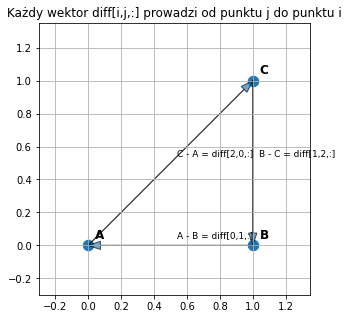

In [35]:
display(Markdown("### 7. Wizualizacja wybranych różnic jako strzałek"))

fig, ax = plt.subplots(figsize=(5.5, 5.0))

ax.scatter(X_demo[:, 0], X_demo[:, 1], s=110)

for lab, (x, y) in zip(labels_demo, X_demo):
    ax.text(x + 0.04, y + 0.04, lab, fontsize=12, weight="bold")

# diff[i,j,:] = x_i - x_j, więc strzałka prowadzi od punktu j do punktu i.
arrow_examples = [
    (0, 1, "A - B = diff[0,1,:]"),
    (1, 2, "B - C = diff[1,2,:]"),
    (2, 0, "C - A = diff[2,0,:]")
]

for i, j, label in arrow_examples:
    start = X_demo[j]
    delta = X_demo[i] - X_demo[j]
    ax.arrow(
        start[0], start[1],
        delta[0], delta[1],
        head_width=0.05,
        length_includes_head=True,
        alpha=0.65
    )
    midpoint = start + 0.5 * delta
    ax.text(midpoint[0] + 0.04, midpoint[1] + 0.04, label, fontsize=9)

ax.set_title("Każdy wektor diff[i,j,:] prowadzi od punktu j do punktu i")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.3, 1.35)
ax.set_ylim(-0.3, 1.35)
plt.show()

## 0.2. Funkcje pomocnicze: punkty i grafy

Te funkcje służą tylko do rysowania.

- `plot_points(...)` pokazuje punkty na płaszczyźnie.
- `plot_graph(...)` pokazuje połączenia zapisane w macierzy sąsiedztwa.

Jeśli macierz sąsiedztwa ma wartość $A_{ij}=1$, rysujemy krawędź między punktami $i$ oraz $j$.


In [36]:
def plot_points(X, labels, y=None, title='punkty', annotate=True, ax=None, extra_points=None):
    X = np.asarray(X, dtype=float)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.5))

    if y is None:
        ax.scatter(X[:, 0], X[:, 1], s=90)
    else:
        y = np.asarray(y)
        for val in np.unique(y):
            mask = y == val
            ax.scatter(X[mask, 0], X[mask, 1], s=90, label=f'klasa {val}')
        ax.legend()

    if annotate:
        for lab, (xv, yv) in zip(labels, X):
            ax.text(xv + 0.04, yv + 0.04, str(lab), fontsize=11, weight='bold')

    if extra_points:
        for lab, pt in extra_points.items():
            ax.scatter([pt[0]], [pt[1]], marker='*', s=160)
            ax.text(pt[0] + 0.06, pt[1] + 0.06, lab, fontsize=12, weight='bold')

    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    return ax


def plot_graph(X, labels, A, title='', directed=False, ax=None):
    X = np.asarray(X, dtype=float)
    A = np.asarray(A)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.5))

    ax.scatter(X[:, 0], X[:, 1], s=120)
    for i, lab in enumerate(labels):
        ax.text(X[i, 0] + 0.04, X[i, 1] + 0.04, str(lab), fontsize=11, weight='bold')

    n = len(labels)
    for i in range(n):
        for j in range(n):
            if i == j or A[i, j] == 0:
                continue
            if not directed and j < i:
                continue

            x1, y1 = X[i]
            x2, y2 = X[j]
            if directed:
                ax.annotate(
                    '', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', alpha=0.45, lw=1.2)
                )
            else:
                ax.plot([x1, x2], [y1, y2], alpha=0.45)

    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    return ax


## 0.3. Dane przykładowe

Będziemy pracować na sześciu punktach.

Punkty `A, B, C` tworzą jedną lokalną grupę, a punkty `D, E, F` drugą lokalną grupę. To jest celowe: dzięki temu będzie dobrze widać, kiedy graf zachowuje dwie grupy, a kiedy parametry sztucznie tworzą most między nimi.


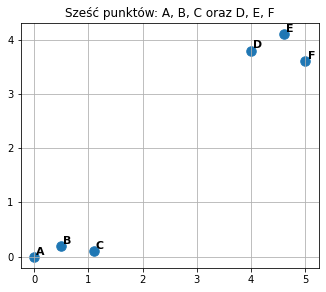

In [37]:
labels = np.array(list('ABCDEF'))

X = np.array([
    [0.0, 0.0],   # A
    [0.5, 0.2],   # B
    [1.1, 0.1],   # C
    [4.0, 3.8],   # D
    [4.6, 4.1],   # E
    [5.0, 3.6],   # F
])

plot_points(X, labels, title='Sześć punktów: A, B, C oraz D, E, F')
plt.show()


## Punkty jako macierz danych

Każdy wiersz odpowiada jednemu punktowi.

$$
X=
\begin{bmatrix}
0.0 & 0.0\\
0.5 & 0.2\\
1.1 & 0.1\\
4.0 & 3.8\\
4.6 & 4.1\\
5.0 & 3.6
\end{bmatrix}
$$

Pierwsza kolumna to współrzędna $x$,
druga kolumna to współrzędna $y$.

In [38]:
pd.DataFrame(
    X,
    index=labels,
    columns=["x", "y"]
)

,x,y
A,0.0,0.0
B,0.5,0.2
C,1.1,0.1
D,4.0,3.8
E,4.6,4.1
F,5.0,3.6


Mamy:

- 6 punktów
- 2 współrzędne

czyli

$$
X \in \mathbb{R}^{6\times 2}.
$$

In [39]:
print("X.shape =", X.shape)

X.shape = (6, 2)


### Minićwiczenie 1 — odczytywanie punktów z macierzy $X$

Zanim przejdziemy dalej, odpowiedz:

1. Który wiersz macierzy $X$ odpowiada punktowi $C$?
2. Jakie współrzędne ma punkt $E$?
3. Ile punktów i ile współrzędnych ma macierz $X$?

<details>
<summary><strong>Rozwiązanie minićwiczenia 1</strong></summary>

1. Punkt $C$ odpowiada trzeciemu wierszowi tabeli, czyli indeksowi `2` w Pythonie: $X[2]$.
2. Punkt $E$ ma współrzędne $(4.6, 4.1)$.
3. Macierz danych ma kształt $X \in \mathbb{R}^{6\times 2}$, czyli mamy 6 punktów i 2 współrzędne.

Najważniejszy wniosek: każdy wiersz macierzy $X$ to jeden punkt danych.
</details>

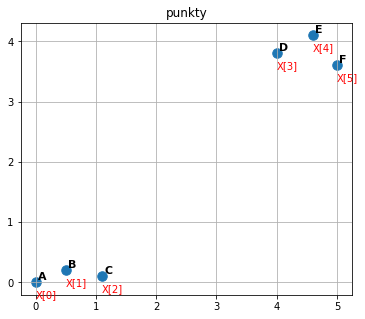

In [40]:
fig, ax = plt.subplots(figsize=(7,5))

plot_points(X, labels, ax=ax)

for i,(xv,yv) in enumerate(X):
    ax.text(
        xv,
        yv-0.25,
        f"X[{i}]",
        color='red'
    )

plt.show()


## Co zauważamy?

Wizualnie widzimy dwie grupy:

- A, B, C
- D, E, F

Człowiek widzi je natychmiast.

Komputer jeszcze nie.

Dla komputera to tylko liczby zapisane w macierzy $X$.

In [41]:
display(Markdown("### Wszystkie pary punktów"))

for i, lab_i in enumerate(labels):
    for j, lab_j in enumerate(labels):
        print(f"({lab_i},{lab_j})", end="  ")
    print()

### Wszystkie pary punktów

(A,A)  (A,B)  (A,C)  (A,D)  (A,E)  (A,F)  
(B,A)  (B,B)  (B,C)  (B,D)  (B,E)  (B,F)  
(C,A)  (C,B)  (C,C)  (C,D)  (C,E)  (C,F)  
(D,A)  (D,B)  (D,C)  (D,D)  (D,E)  (D,F)  
(E,A)  (E,B)  (E,C)  (E,D)  (E,E)  (E,F)  
(F,A)  (F,B)  (F,C)  (F,D)  (F,E)  (F,F)  


## 1. Macierz odległości

Dla punktów w 2D używamy odległości euklidesowej:

$$
d(x_i,x_j)=\sqrt{(x_{i1}-x_{j1})^2+(x_{i2}-x_{j2})^2}.
$$

Przykład:

$$
A=(0,0), \qquad B=(0.5,0.2)
$$

$$
d(A,B)=\sqrt{(0-0.5)^2+(0-0.2)^2}
=\sqrt{0.25+0.04}
=\sqrt{0.29}\approx 0.54.
$$


### Minićwiczenie 2 — zanim policzymy całą macierz odległości

Spróbuj przewidzieć bez uruchamiania kolejnej komórki:

1. Dlaczego przekątna macierzy $D$ powinna składać się z samych zer?
2. Która odległość powinna być mniejsza: $d(A,B)$ czy $d(A,D)$?
3. Czy macierz odległości $D$ powinna być symetryczna, czyli czy $D_{ij}=D_{ji}$?

**Macierz odległości D**

,A,B,C,D,E,F
A,0.00,0.54,1.10,5.52,6.16,6.16
B,0.54,0.00,0.61,5.02,5.66,5.64
C,1.10,0.61,0.00,4.70,5.32,5.24
D,5.52,5.02,4.70,0.00,0.67,1.02
E,6.16,5.66,5.32,0.67,0.00,0.64
F,6.16,5.64,5.24,1.02,0.64,0.00


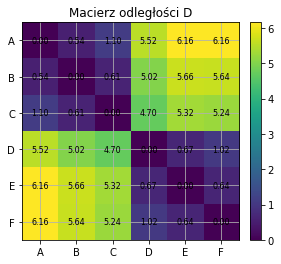

In [42]:
D = pairwise_distances(X)
show_matrix(D, labels, 'Macierz odległości D', number_format='.2f', cmap='viridis')


<details>
<summary><strong>Rozwiązanie minićwiczenia 2</strong></summary>

1. Przekątna macierzy $D$ to odległości punktów od samych siebie, więc zawsze mamy $D_{ii}=0$.
2. $d(A,B)$ jest dużo mniejsze niż $d(A,D)$, bo $A$ i $B$ leżą w tej samej lokalnej grupie, a $D$ leży daleko w drugiej grupie.
3. Tak, macierz odległości euklidesowych jest symetryczna, ponieważ $d(x_i,x_j)=d(x_j,x_i)$.

Najważniejszy wniosek: macierz $D$ mówi, jak daleko są wszystkie pary punktów, ale sama jeszcze nie mówi, które punkty połączyć krawędzią.
</details>

### Czy sama macierz odległości jest już grafem?

Jeszcze nie.

Macierz odległości mówi tylko **jak daleko** są punkty od siebie. Żeby dostać graf, musimy podjąć dodatkową decyzję:

> kiedy dwa punkty uznajemy za sąsiadów?

Są dwa najprostsze pomysły:

1. **promień $\varepsilon$** — łączymy punkty, jeśli są bliżej niż zadany próg,
2. **$k$ najbliższych sąsiadów** — każdy punkt wybiera dokładnie $k$ najbliższych punktów.

To przejście jest kluczowe: **algorytm nie dostaje grafu za darmo — graf powstaje z decyzji o sąsiedztwie**.


In [43]:
display(Markdown("### Jak czytać macierz odległości?"))

examples = [
    ("A", "B", D[0,1]),
    ("A", "D", D[0,3]),
    ("D", "E", D[3,4]),
]

pd.DataFrame(
    examples,
    columns=["punkt 1", "punkt 2", "odległość"]
)

### Jak czytać macierz odległości?

,punkt 1,punkt 2,odległość
0,A,B,0.539
1,A,D,5.517
2,D,E,0.671


Każdy element

$$
D_{ij}
$$

oznacza odległość pomiędzy punktami

$$
x_i
$$

oraz

$$
x_j.
$$

Przekątna jest zawsze równa zero, ponieważ odległość punktu od samego siebie wynosi:

$$
D_{ii}=0.
$$

### Macierz i graf to dwie reprezentacje tej samej decyzji

W tej części warto pamiętać:

- macierz odległości $D$ mówi, jak daleko są punkty,
- macierz sąsiedztwa $A$ mówi, które punkty łączymy,
- graf jest geometrycznym rysunkiem tej samej informacji zapisanej w macierzy $A$.

Czyli przejście jest następujące:

```text
Dane X → odległości D → reguła sąsiedztwa → macierz A → graf
```

## 2. Pierwsza macierz sąsiedztwa: promień $\varepsilon$

Najprostszy pomysł:

$$
A_{ij}=\begin{cases}
1, & 0<d(x_i,x_j)\leq \varepsilon,\\
0, & \text{w przeciwnym razie.}
\end{cases}
$$

Czyli: stawiamy `1`, jeśli dwa punkty są w promieniu $\varepsilon$.
Na przekątnej dajemy `0`, bo zwykle nie rysujemy krawędzi punktu do samego siebie.


### Minićwiczenie 3 — zanim zbudujemy macierz $\varepsilon$-sąsiedztwa

Dla trzech wartości $\varepsilon$: małej, średniej i dużej spróbuj przewidzieć:

1. Co stanie się, gdy $\varepsilon$ będzie zbyt małe?
2. Co stanie się, gdy $\varepsilon$ będzie bardzo duże?
3. Która wartość $\varepsilon$ może zachować dwie grupy: `ABC` oraz `DEF`?

**Macierz epsilon-sąsiedztwa, eps=0.8**

,A,B,C,D,E,F
A,0,1,0,0,0,0
B,1,0,1,0,0,0
C,0,1,0,0,0,0
D,0,0,0,0,1,0
E,0,0,0,1,0,1
F,0,0,0,0,1,0


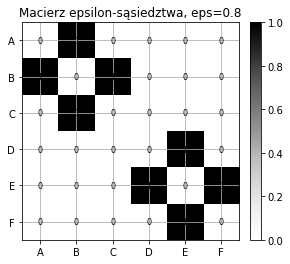

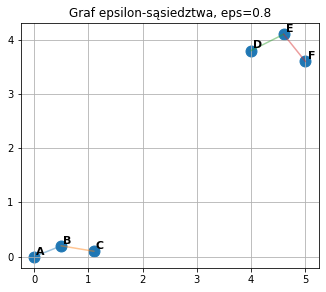

**Macierz epsilon-sąsiedztwa, eps=1.2**

,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,1,0,0,0
C,1,1,0,0,0,0
D,0,0,0,0,1,1
E,0,0,0,1,0,1
F,0,0,0,1,1,0


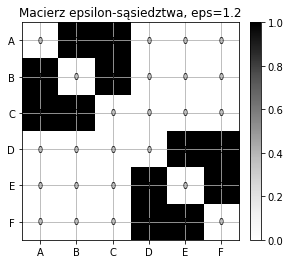

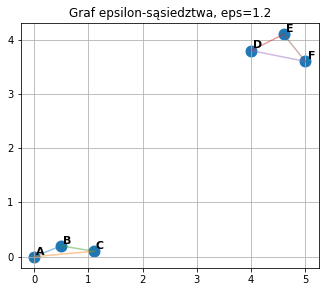

**Macierz epsilon-sąsiedztwa, eps=5.0**

,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,1,0,0,0
C,1,1,0,1,0,0
D,0,0,1,0,1,1
E,0,0,0,1,0,1
F,0,0,0,1,1,0


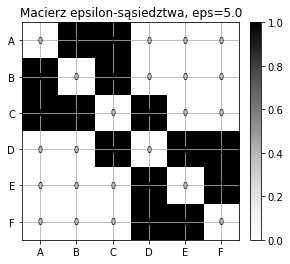

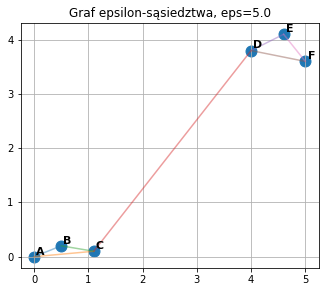

In [44]:
def adjacency_eps(D, eps):
    """Macierz sąsiedztwa dla progu eps.

    A[i, j] = 1, gdy punkt j leży w promieniu eps od punktu i.
    """
    A = ((D <= eps) & (D > 0)).astype(int)
    return A

for eps in [0.8, 1.2, 5.0]:
    A_eps = adjacency_eps(D, eps)
    show_matrix(
        A_eps, labels,
        f'Macierz epsilon-sąsiedztwa, eps={eps}',
        number_format='.0f', cmap='Greys', vmin=0, vmax=1
    )
    plot_graph(X, labels, A_eps, title=f'Graf epsilon-sąsiedztwa, eps={eps}', directed=False)
    plt.show()


### Co pokazało $\varepsilon$-sąsiedztwo?

Dla małego $\varepsilon$ dostajemy tylko bardzo lokalne połączenia. Dla dużego $\varepsilon$ graf szybko zaczyna łączyć odległe grupy.

To jest intuicja potrzebna później w **DBSCAN**:

```text
małe eps  → punkty widzą tylko najbliższe otoczenie
duże eps  → różne skupiska mogą się sztucznie połączyć
```

Wniosek dydaktyczny: parametr $\varepsilon$ nie jest tylko technicznym suwakiem. On definiuje, **co znaczy lokalność**.


<details>
<summary><strong>Rozwiązanie minićwiczenia 3</strong></summary>

1. Gdy $\varepsilon$ jest zbyt małe, wiele punktów nie ma żadnych sąsiadów albo graf rozpada się na bardzo małe fragmenty.
2. Gdy $\varepsilon$ jest bardzo duże, pojawia się dużo krawędzi i dwie odległe grupy mogą zostać sztucznie połączone.
3. Dobra wartość $\varepsilon$ powinna być większa niż odległości wewnątrz grup `ABC` i `DEF`, ale mniejsza niż odległość między grupami.

Najważniejszy wniosek: $\varepsilon$ definiuje lokalność. To nie jest detal techniczny, tylko decyzja o tym, kiedy dwa punkty uznajemy za sąsiadów.
</details>

## 3. Macierz kNN: każdy punkt wybiera $k$ najbliższych sąsiadów

W grafie kNN robimy coś innego niż przy $\varepsilon$.

Dla każdego punktu $i$ sortujemy inne punkty po odległości i wybieramy pierwsze $k$:

$$
A_{ij}=1
\quad\Longleftrightarrow\quad
x_j \text{ należy do } k \text{ najbliższych sąsiadów } x_i.
$$

Uwaga: taka macierz jest **kierunkowa**.
Może być tak, że `A` wybiera `B`, ale `B` nie wybiera `A`.


In [45]:
def knn_adjacency(D, k):
    """Kierunkowa macierz kNN.

    Wiersz i mówi, których k punktów jest najbliżej punktu i.
    """
    n = D.shape[0]
    A = np.zeros((n, n), dtype=int)

    for i in range(n):
        order = np.argsort(D[i])
        neighbors = [j for j in order if j != i][:k]
        A[i, neighbors] = 1

    return A


def knn_table(D, labels, k):
    """Tabela kNN bez pustych pól i bez kolumn zależnych od etykiet sąsiadów.

    Używamy stałych kolumn: `1. sąsiad`, `d1`, `2. sąsiad`, `d2`, ...
    Dzięki temu każdy wiersz ma ten sam układ.
    """
    rows = []
    for i, lab in enumerate(labels):
        order = [j for j in np.argsort(D[i]) if j != i][:k]
        row = {'punkt': lab}
        for r, j in enumerate(order, start=1):
            row[f'{r}. sąsiad'] = labels[j]
            row[f'd{r}'] = f'{D[i, j]:.3f}'
        rows.append(row)

    ordered_columns = []
    for r in range(1, k + 1):
        ordered_columns.extend([f'{r}. sąsiad', f'd{r}'])

    return pd.DataFrame(rows).set_index('punkt')[ordered_columns]


for k in [1, 2, 3]:
    display(Markdown(f'**$k={k}$: najbliżsi sąsiedzi**'))
    display(knn_table(D, labels, k))


**$k=1$: najbliżsi sąsiedzi**

,1. sąsiad,d1
punkt,,
A,B,0.539
B,A,0.539
C,B,0.608
D,E,0.671
E,F,0.640
F,E,0.640


**$k=2$: najbliżsi sąsiedzi**

,1. sąsiad,d1,2. sąsiad,d2
punkt,,,,
A,B,0.539,C,1.105
B,A,0.539,C,0.608
C,B,0.608,A,1.105
D,E,0.671,F,1.020
E,F,0.640,D,0.671
F,E,0.640,D,1.020


**$k=3$: najbliżsi sąsiedzi**

,1. sąsiad,d1,2. sąsiad,d2,3. sąsiad,d3
punkt,,,,,,
A,B,0.539,C,1.105,D,5.517
B,A,0.539,C,0.608,D,5.021
C,B,0.608,A,1.105,D,4.701
D,E,0.671,F,1.020,C,4.701
E,F,0.640,D,0.671,C,5.315
F,E,0.640,D,1.020,C,5.240


### Minićwiczenie 4 — graf $k$NN

Nie uruchamiaj jeszcze komórki z grafami $k$NN. Spróbuj przewidzieć:

1. Ilu sąsiadów będzie miał każdy punkt dla $k=1$?
2. Ilu sąsiadów będzie miał każdy punkt dla $k=2$?
3. Czy dla $k=2$ powinno pojawić się połączenie między grupami `ABC` oraz `DEF`?
4. Co zmieni się dla $k=3$?

## 4. Kierunkowa macierz kNN

W tej wersji każdy wiersz ma dokładnie $k$ jedynek.

Interpretacja wiersza:

> wiersz `A` mówi, kogo punkt `A` wskazuje jako swoich sąsiadów.

To jest ważne, bo graf $k$NN w pierwszym kroku zwykle jest **grafem skierowanym**.


**Kierunkowa macierz kNN, k=1**

,A,B,C,D,E,F
A,0,1,0,0,0,0
B,1,0,0,0,0,0
C,0,1,0,0,0,0
D,0,0,0,0,1,0
E,0,0,0,0,0,1
F,0,0,0,0,1,0


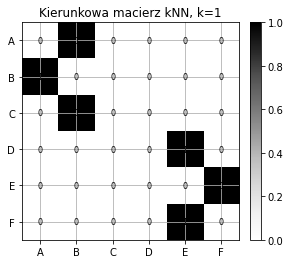

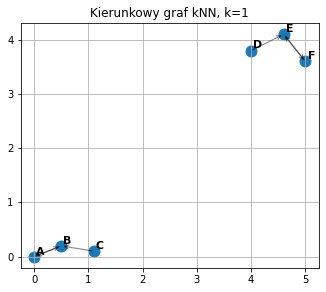

**Kierunkowa macierz kNN, k=2**

,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,1,0,0,0
C,1,1,0,0,0,0
D,0,0,0,0,1,1
E,0,0,0,1,0,1
F,0,0,0,1,1,0


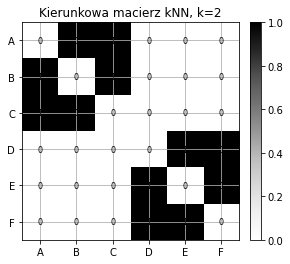

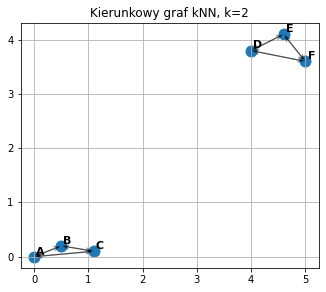

**Kierunkowa macierz kNN, k=3**

,A,B,C,D,E,F
A,0,1,1,1,0,0
B,1,0,1,1,0,0
C,1,1,0,1,0,0
D,0,0,1,0,1,1
E,0,0,1,1,0,1
F,0,0,1,1,1,0


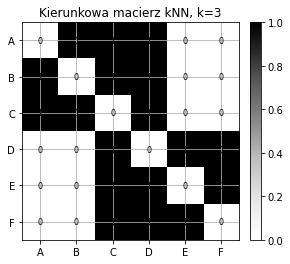

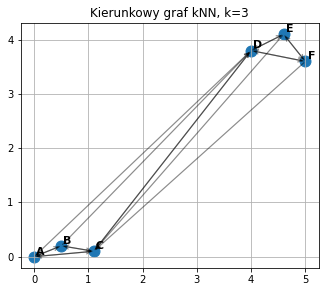

In [46]:
for k in [1, 2, 3]:
    A_knn = knn_adjacency(D, k)
    show_matrix(
        A_knn, labels,
        f'Kierunkowa macierz kNN, k={k}',
        number_format='.0f', cmap='Greys', vmin=0, vmax=1
    )
    plot_graph(X, labels, A_knn, title=f'Kierunkowy graf kNN, k={k}', directed=True)
    plt.show()


<details>
<summary><strong>Rozwiązanie minićwiczenia 4</strong></summary>

1. Dla $k=1$ każdy punkt wskazuje dokładnie jednego najbliższego sąsiada.
2. Dla $k=2$ każdy punkt wskazuje dokładnie dwóch najbliższych sąsiadów.
3. Dla $k=2$ grupy `ABC` oraz `DEF` powinny zasadniczo pozostać oddzielne, bo każdy punkt ma dwóch naturalnych sąsiadów wewnątrz swojej grupy.
4. Dla $k=3$ każdy punkt musi wskazać trzech sąsiadów. Ponieważ w swojej lokalnej grupie ma tylko dwóch bliskich sąsiadów, trzeci sąsiad musi pochodzić z drugiej grupy.

Najważniejszy wniosek: zbyt duże $k$ może wymusić połączenia między grupami, które geometrycznie wyglądają na oddzielne.
</details>

### Sprawdźmy asymetrię kNN

Macierz kNN jest kierunkowa, bo pytanie brzmi:

> czy $x_j$ należy do listy najbliższych sąsiadów punktu $x_i$?

To nie musi oznaczać, że $x_i$ należy do listy najbliższych sąsiadów punktu $x_j$.

Poniższa komórka wypisuje pary, dla których zachodzi tylko jedna z relacji: `A → B` albo `B → A`.


### Minićwiczenie 5 — asymetria $k$NN

Spójrz na kierunkowy graf $k$NN i odpowiedz:

1. Czy jeśli punkt $A$ wskazuje punkt $B$, to punkt $B$ musi wskazywać punkt $A$?
2. Dlaczego relacja „bycia wśród $k$ najbliższych sąsiadów” może działać tylko w jedną stronę?

In [47]:
def asymmetric_knn_pairs(A, labels):
    """Wypisuje pary, w których relacja sąsiedztwa działa tylko w jedną stronę."""
    rows = []
    n = A.shape[0]

    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] != A[j, i]:
                if A[i, j] == 1:
                    rows.append({
                        'para': f'{labels[i]}–{labels[j]}',
                        'relacja': f'{labels[i]} → {labels[j]}',
                        'odwrotnie?': 'nie'
                    })
                else:
                    rows.append({
                        'para': f'{labels[i]}–{labels[j]}',
                        'relacja': f'{labels[j]} → {labels[i]}',
                        'odwrotnie?': 'nie'
                    })

    return pd.DataFrame(rows)


for k in [1, 2, 3]:
    display(Markdown(f'**Asymetryczne relacje dla $k={k}$**'))
    asym = asymmetric_knn_pairs(knn_adjacency(D, k), labels)

    if len(asym) == 0:
        display(Markdown('Brak asymetrycznych relacji — ta konkretna macierz jest już symetryczna.'))
    else:
        display(asym)


**Asymetryczne relacje dla $k=1$**

,para,relacja,odwrotnie?
0,B–C,C → B,nie
1,D–E,D → E,nie


**Asymetryczne relacje dla $k=2$**

Brak asymetrycznych relacji — ta konkretna macierz jest już symetryczna.

**Asymetryczne relacje dla $k=3$**

,para,relacja,odwrotnie?
0,A–D,A → D,nie
1,B–D,B → D,nie
2,C–E,E → C,nie
3,C–F,F → C,nie


### Dlaczego $k$NN nie jest symetryczny?

Możemy mieć relację:

```text
A → B
```

bo $B$ jest jednym z najbliższych sąsiadów punktu $A$.

Ale jednocześnie może nie być relacji:

```text
B → A
```

bo punkt $B$ może mieć bliższych sąsiadów niż $A$.

<details>
<summary><strong>Rozwiązanie minićwiczenia 5</strong></summary>

1. Nie. Może być tak, że $A \to B$, ale nie ma $B \to A$.
2. Dzieje się tak dlatego, że każdy punkt tworzy swoją własną listę najbliższych sąsiadów. Punkt samotny może wskazywać punkt z gęstej grupy, ale punkt z gęstej grupy może mieć bliższych sąsiadów wewnątrz tej grupy.

Najważniejszy wniosek: graf $k$NN jest najpierw grafem skierowanym. Dopiero później możemy zdecydować, jak go symetryzować.
</details>

## 5. Symetryzacja: dwa różne warianty

Często chcemy graf bez kierunku. Są dwa popularne sposoby.

### Wariant 1: union / OR

Łączymy punkty, jeśli **chociaż jeden** wskazał drugiego:

$$
A^{\mathrm{union}}_{ij}=\max(A_{ij},A_{ji}).
$$

To jest częsty wybór w grafach sąsiedztwa, bo zachowuje więcej połączeń.

### Wariant 2: mutual / AND

Łączymy punkty tylko wtedy, gdy **oba** wskazały siebie nawzajem:

$$
A^{\mathrm{mutual}}_{ij}=\min(A_{ij},A_{ji}).
$$

To jest ostrzejsze i często usuwa mosty między grupami.


### Minićwiczenie 6 — union/OR czy mutual/AND?

Zanim uruchomisz komórkę z symetryzacją, spróbuj przewidzieć:

1. Który graf będzie gęstszy: `union/OR` czy `mutual/AND`?
2. Który wariant łatwiej tworzy mosty między grupami?
3. Który wariant zostawia tylko silniejsze, wzajemne relacje sąsiedztwa?

**Symetryczna macierz kNN: union/OR, k=1**

,A,B,C,D,E,F
A,0,1,0,0,0,0
B,1,0,1,0,0,0
C,0,1,0,0,0,0
D,0,0,0,0,1,0
E,0,0,0,1,0,1
F,0,0,0,0,1,0


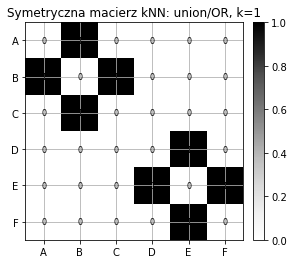

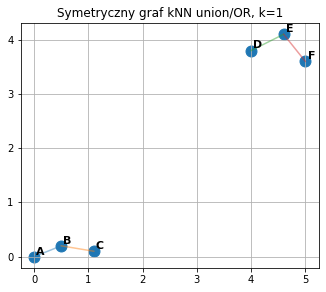

**Symetryczna macierz kNN: mutual/AND, k=1**

,A,B,C,D,E,F
A,0,1,0,0,0,0
B,1,0,0,0,0,0
C,0,0,0,0,0,0
D,0,0,0,0,0,0
E,0,0,0,0,0,1
F,0,0,0,0,1,0


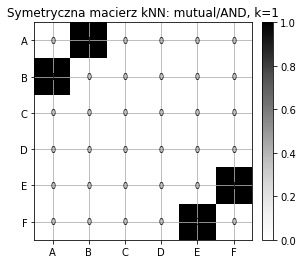

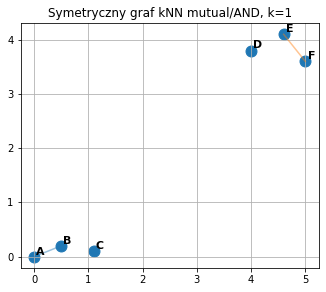

**Symetryczna macierz kNN: union/OR, k=2**

,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,1,0,0,0
C,1,1,0,0,0,0
D,0,0,0,0,1,1
E,0,0,0,1,0,1
F,0,0,0,1,1,0


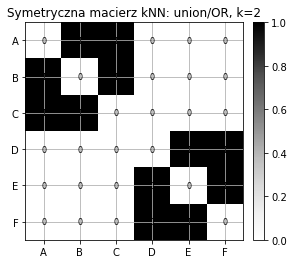

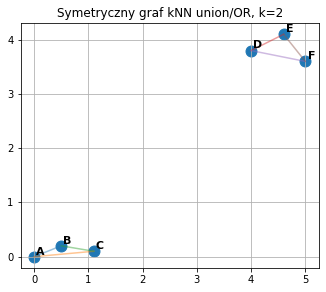

**Symetryczna macierz kNN: mutual/AND, k=2**

,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,1,0,0,0
C,1,1,0,0,0,0
D,0,0,0,0,1,1
E,0,0,0,1,0,1
F,0,0,0,1,1,0


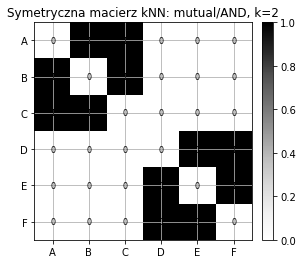

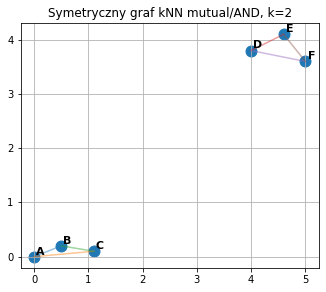

**Symetryczna macierz kNN: union/OR, k=3**

,A,B,C,D,E,F
A,0,1,1,1,0,0
B,1,0,1,1,0,0
C,1,1,0,1,1,1
D,1,1,1,0,1,1
E,0,0,1,1,0,1
F,0,0,1,1,1,0


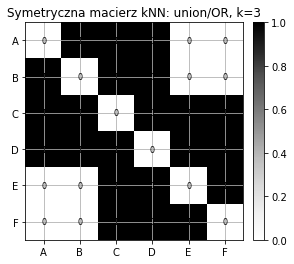

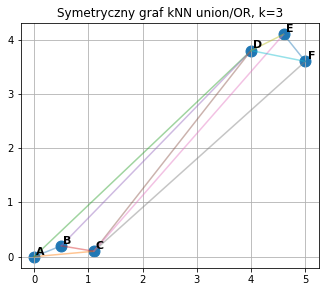

**Symetryczna macierz kNN: mutual/AND, k=3**

,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,1,0,0,0
C,1,1,0,1,0,0
D,0,0,1,0,1,1
E,0,0,0,1,0,1
F,0,0,0,1,1,0


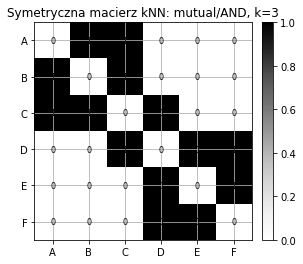

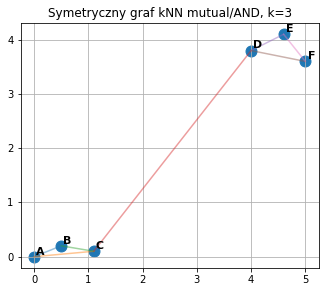

In [48]:
def sym_union(A):
    """Symetryzacja OR: wystarczy, że jedna strona wskazuje drugą."""
    return np.maximum(A, A.T)


def sym_mutual(A):
    """Symetryzacja AND: obie strony muszą wskazywać siebie nawzajem."""
    return np.minimum(A, A.T)


for k in [1, 2, 3]:
    A_dir = knn_adjacency(D, k)
    A_union = sym_union(A_dir)
    A_mutual = sym_mutual(A_dir)

    show_matrix(
        A_union, labels,
        f'Symetryczna macierz kNN: union/OR, k={k}',
        number_format='.0f', cmap='Greys', vmin=0, vmax=1
    )
    plot_graph(X, labels, A_union, title=f'Symetryczny graf kNN union/OR, k={k}', directed=False)
    plt.show()

    show_matrix(
        A_mutual, labels,
        f'Symetryczna macierz kNN: mutual/AND, k={k}',
        number_format='.0f', cmap='Greys', vmin=0, vmax=1
    )
    plot_graph(X, labels, A_mutual, title=f'Symetryczny graf kNN mutual/AND, k={k}', directed=False)
    plt.show()


<details>
<summary><strong>Rozwiązanie minićwiczenia 6</strong></summary>

1. Graf `union/OR` będzie gęstszy, bo wystarczy, że jedna strona wskaże drugą.
2. `union/OR` łatwiej tworzy mosty między grupami, bo zachowuje więcej krawędzi.
3. `mutual/AND` zostawia tylko wzajemne relacje, czyli takie, w których $A$ wskazuje $B$ i jednocześnie $B$ wskazuje $A$.

W sensie liczby krawędzi zwykle mamy:

$$
A^{\mathrm{mutual}} \leq A^{\mathrm{union}}.
$$

Najważniejszy wniosek: `union/OR` jest bardziej liberalny, a `mutual/AND` bardziej konserwatywny.
</details>

### Minićwiczenie 7 — dlaczego $k=3$ jest podejrzane w tym przykładzie?

Mamy dwie lokalne grupy po trzy punkty:

$$
\{A,B,C\}, \qquad \{D,E,F\}.
$$

Zanim obejrzysz macierze dla $k=3$, odpowiedz:

1. Ilu naturalnych sąsiadów ma punkt $A$ wewnątrz swojej grupy?
2. Co musi się stać, jeśli wymusimy $k=3$?
3. Czy most między grupami oznacza błąd kodu?

**Kierunkowa macierz kNN dla $k=3$**

,A,B,C,D,E,F
A,0,1,1,1,0,0
B,1,0,1,1,0,0
C,1,1,0,1,0,0
D,0,0,1,0,1,1
E,0,0,1,1,0,1
F,0,0,1,1,1,0


**Union/OR: krawędź istnieje, jeśli $A$ wybiera $B$ lub $B$ wybiera $A$**

,A,B,C,D,E,F
A,0,1,1,1,0,0
B,1,0,1,1,0,0
C,1,1,0,1,1,1
D,1,1,1,0,1,1
E,0,0,1,1,0,1
F,0,0,1,1,1,0


**Mutual/AND: krawędź istnieje, jeśli $A$ wybiera $B$ i $B$ wybiera $A$**

,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,1,0,0,0
C,1,1,0,1,0,0
D,0,0,1,0,1,1
E,0,0,0,1,0,1
F,0,0,0,1,1,0


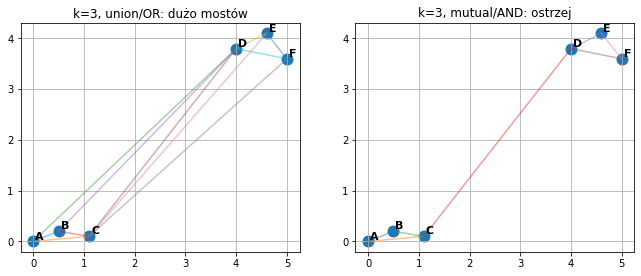

In [49]:
k = 3
A3 = knn_adjacency(D, k)

idx_labels = labels

example_tables = [
    ('Kierunkowa macierz kNN dla $k=3$', A3),
    ('Union/OR: krawędź istnieje, jeśli $A$ wybiera $B$ lub $B$ wybiera $A$', sym_union(A3)),
    ('Mutual/AND: krawędź istnieje, jeśli $A$ wybiera $B$ i $B$ wybiera $A$', sym_mutual(A3)),
]

for title, matrix in example_tables:
    display(Markdown(f'**{title}**'))
    display(format_matrix_for_display(matrix, idx_labels, number_format='.0f'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_graph(X, labels, sym_union(A3), title='k=3, union/OR: dużo mostów', ax=axes[0])
plot_graph(X, labels, sym_mutual(A3), title='k=3, mutual/AND: ostrzej', ax=axes[1])
plt.show()


<details>
<summary><strong>Rozwiązanie minićwiczenia 7</strong></summary>

1. Punkt $A$ ma tylko dwóch naturalnych sąsiadów wewnątrz grupy `ABC`: punkty $B$ i $C$.
2. Jeśli wymusimy $k=3$, trzeci sąsiad musi zostać wybrany z drugiej grupy, czyli z `DEF`.
3. Nie. Most między grupami nie oznacza błędu kodu. To konsekwencja definicji $k$NN i zbyt dużej wartości $k$ dla tak małego przykładu.

Najważniejszy wniosek: parametr $k$ zmienia topologię grafu. Dla zbyt dużego $k$ graf może przestać odzwierciedlać lokalną strukturę danych.
</details>

## 7. Interaktywny panel: jak $\varepsilon$ i $k$ zmieniają graf?

Ta komórka dodaje dwa panele:

1. **panel $\varepsilon$** — pokazuje, jak próg odległości zmienia graf sąsiedztwa,
2. **panel $k$** — porównuje symetryzację `union/OR` i `mutual/AND` dla różnych wartości $k$.

Dydaktycznie to jest bardzo dobry moment na pytania:

- kiedy dwie grupy zaczynają się łączyć?
- czy `union/OR` zawsze daje więcej krawędzi niż `mutual/AND`?
- co się stanie, gdy $k$ będzie zbyt duże względem liczby punktów w lokalnej grupie?


### Minićwiczenie 8 — panel interaktywny

Podczas pracy z suwakiem sprawdź:

1. Dla jakiej wartości $\varepsilon$ graf zaczyna łączyć grupy `ABC` i `DEF`?
2. Dla jakiego $k$ pojawiają się mosty między grupami?
3. Czy `union/OR` i `mutual/AND` zachowują się tak samo?

In [50]:
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    from pathlib import Path

    html_dir = Path('html')
    html_dir.mkdir(parents=True, exist_ok=True)


    def edge_xy_for_plotly(X, A, directed=False):
        xs, ys = [], []
        n = A.shape[0]

        for i in range(n):
            for j in range(n):
                if i == j or A[i, j] == 0:
                    continue
                if not directed and j <= i:
                    continue
                xs.extend([X[i, 0], X[j, 0], None])
                ys.extend([X[i, 1], X[j, 1], None])

        return xs, ys


    # Panel 1: epsilon-neighborhood
    # --------------------------------
    eps_values = [0.6, 0.8, 1.0, 1.2, 2.0, 3.0, 5.0]
    active_eps_idx = eps_values.index(1.2)

    fig_eps = make_subplots(
        rows=1, cols=2,
        subplot_titles=('graf epsilon-sąsiedztwa', 'macierz sąsiedztwa A(eps)'),
        specs=[[{'type': 'scatter'}, {'type': 'heatmap'}]],
        column_widths=[0.55, 0.45]
    )

    # Najpierw krawędzie i macierze dla kolejnych eps.
    for idx, eps_value in enumerate(eps_values):
        A_eps = adjacency_eps(D, eps_value)
        xs, ys = edge_xy_for_plotly(X, A_eps, directed=False)
        visible = idx == active_eps_idx

        fig_eps.add_trace(
            go.Scatter(
                x=xs, y=ys, mode='lines', name=f'krawędzie, eps={eps_value}',
                visible=visible, hoverinfo='skip', showlegend=False, line=dict(width=3)
            ),
            row=1, col=1
        )
        fig_eps.add_trace(
            go.Heatmap(
                z=A_eps, x=labels, y=labels, zmin=0, zmax=1,
                colorscale='Greys', showscale=False, visible=visible,
                hovertemplate='i=%{y}<br>j=%{x}<br>A=%{z}<extra></extra>'
            ),
            row=1, col=2
        )

    # Punkty dodajemy na końcu, żeby nie przykryły ich krawędzie.
    fig_eps.add_trace(
        go.Scatter(
            x=X[:, 0], y=X[:, 1], mode='markers+text', text=labels,
            textposition='top center', marker=dict(size=14), name='punkty', showlegend=False
        ),
        row=1, col=1
    )

    steps = []
    for idx, eps_value in enumerate(eps_values):
        A_eps = adjacency_eps(D, eps_value)
        edge_count = int(A_eps.sum() // 2)
        visible = [False] * (2 * len(eps_values)) + [True]
        visible[2 * idx] = True
        visible[2 * idx + 1] = True
        steps.append(dict(
            method='update',
            label=str(eps_value),
            args=[{'visible': visible},
                  {'title': f'Próg eps={eps_value}: liczba krawędzi={edge_count}'}]
        ))

    fig_eps.update_layout(
        title='Próg eps definiuje, co znaczy „wystarczająco blisko”',
        sliders=[dict(active=active_eps_idx, currentvalue={'prefix': 'eps = '}, steps=steps)],
        height=520
    )
    fig_eps.update_xaxes(scaleanchor='y', scaleratio=1, row=1, col=1)
    fig_eps.update_yaxes(autorange='reversed', row=1, col=2)
    fig_eps.write_html(html_dir / '0_1_panel_eps_sasiedztwo.html', include_plotlyjs='cdn')
    fig_eps.show()


    # Panel 2: kNN union vs mutual
    # -----------------------------
    k_values = [1, 2, 3, 4]
    active_k_idx = 1

    fig_knn = make_subplots(
        rows=1, cols=2,
        subplot_titles=('symetryzacja union/OR', 'symetryzacja mutual/AND'),
        specs=[[{'type': 'scatter'}, {'type': 'scatter'}]],
        column_widths=[0.5, 0.5]
    )

    # Krawędzie dla kolejnych k.
    for idx, k_value in enumerate(k_values):
        A_dir = knn_adjacency(D, k_value)
        A_union = sym_union(A_dir)
        A_mutual = sym_mutual(A_dir)
        visible = idx == active_k_idx

        for A_plot, col, variant in [(A_union, 1, 'union'), (A_mutual, 2, 'mutual')]:
            xs, ys = edge_xy_for_plotly(X, A_plot, directed=False)
            fig_knn.add_trace(
                go.Scatter(
                    x=xs, y=ys, mode='lines', visible=visible,
                    name=f'{variant}, k={k_value}', hoverinfo='skip', showlegend=False,
                    line=dict(width=3)
                ),
                row=1, col=col
            )

    # Punkty dodajemy na końcu w obu panelach.
    for col in [1, 2]:
        fig_knn.add_trace(
            go.Scatter(
                x=X[:, 0], y=X[:, 1], mode='markers+text', text=labels,
                textposition='top center', marker=dict(size=14), name='punkty', showlegend=False
            ),
            row=1, col=col
        )

    steps = []
    for idx, k_value in enumerate(k_values):
        A_dir = knn_adjacency(D, k_value)
        A_union = sym_union(A_dir)
        A_mutual = sym_mutual(A_dir)
        visible = [False] * (2 * len(k_values)) + [True, True]
        visible[2 * idx] = True
        visible[2 * idx + 1] = True
        steps.append(dict(
            method='update',
            label=str(k_value),
            args=[{'visible': visible},
                  {'title': f'k={k_value}: union ma {int(A_union.sum() // 2)} krawędzi, mutual ma {int(A_mutual.sum() // 2)} krawędzi'}]
        ))

    fig_knn.update_layout(
        title='Ten sam graf kierunkowy kNN można inaczej symetryzować',
        sliders=[dict(active=active_k_idx, currentvalue={'prefix': 'k = '}, steps=steps)],
        height=520
    )
    fig_knn.update_xaxes(scaleanchor='y', scaleratio=1, row=1, col=1)
    fig_knn.update_xaxes(scaleanchor='y2', scaleratio=1, row=1, col=2)
    fig_knn.write_html(html_dir / '0_1_panel_knn_union_mutual.html', include_plotlyjs='cdn')
    fig_knn.show()

except ImportError:
    display(Markdown('Panel interaktywny wymaga pakietu `plotly`. Pozostałe komórki notebooka działają bez niego.'))


<details>
<summary><strong>Rozwiązanie minićwiczenia 8</strong></summary>

1. Graf $\varepsilon$-sąsiedztwa zaczyna łączyć grupy dopiero wtedy, gdy $\varepsilon$ staje się porównywalne z odległością między grupami.
2. Dla tego przykładu mosty pojawiają się szczególnie wyraźnie przy $k=3$, bo każda grupa ma tylko po trzy punkty.
3. Nie. `union/OR` zachowuje więcej krawędzi i szybciej łączy graf, natomiast `mutual/AND` jest ostrzejszy i częściej usuwa słabe, jednostronne połączenia.

Najważniejszy wniosek: parametry $\varepsilon$, $k$ oraz wybór symetryzacji wpływają nie tylko na wygląd rysunku, ale na samą strukturę grafu.
</details>

### Jak połączyć to z następnymi metodami?

Ten notebook powinien być pokazany przed UMAP-em, DBSCAN-em i klasycznym KNN, bo daje wspólny fundament:

```text
odległości
    ↓
sąsiedztwo
    ↓
graf
    ↓
KNN / DBSCAN / UMAP / spectral clustering
```

Najważniejsze przejścia:

- **KNN**: decyzja przez liczbę sąsiadów $k$,
- **DBSCAN**: decyzja przez promień $\varepsilon$ i minimalną liczbę punktów,
- **UMAP**: lokalny graf sąsiedztwa budowany z najbliższych sąsiadów,
- **spectral clustering**: graf lub macierz podobieństwa jako punkt startowy.


## Co dalej?

W tym notebooku zbudowaliśmy trzy obiekty:

1. macierz odległości

$$
D
$$

2. macierz sąsiedztwa

$$
A
$$

3. graf

$$
G=(V,E)
$$

To właśnie te obiekty stanowią fundament wielu metod uczenia maszynowego:

| Metoda | Wykorzystuje |
|---------|---------|
| KNN | D |
| DBSCAN | D + ε-sąsiedztwo |
| UMAP | D + kNN + graf |
| Spectral Clustering | graf |
| Graph Neural Networks | graf |


## 7.5 Podstawowe własności grafu

Do tej pory zbudowaliśmy graf sąsiedztwa. Możemy teraz policzyć kilka jego podstawowych własności:

- liczba wierzchołków,
- liczba krawędzi,
- stopień każdego wierzchołka,
- liczba składowych spójnych.

To pierwsze kroki w kierunku analizy topologii i geometrii grafów.


In [51]:

# Przykład: graf union dla k=2
k=3

A_demo = sym_union(knn_adjacency(D, k))

n_vertices = A_demo.shape[0]
n_edges = int(np.sum(A_demo) // 2)
degrees = A_demo.sum(axis=1)

print("Liczba wierzchołków:", n_vertices)
print("Liczba krawędzi:", n_edges)

display(pd.DataFrame({
    "punkt": labels,
    "stopień": degrees
}))
print("\nŚredni stopień:", degrees.mean())
print("Maksymalny stopień:", degrees.max())
print("Minimalny stopień:", degrees.min())


Liczba wierzchołków: 6
Liczba krawędzi: 11


,punkt,stopień
0,A,3
1,B,3
2,C,5
3,D,5
4,E,3
5,F,3



Średni stopień: 3.6666666666666665
Maksymalny stopień: 5
Minimalny stopień: 3


### Interpretacja

Stopień wierzchołka mówi, ilu sąsiadów ma dany punkt.

- duży stopień → punkt dobrze połączony,
- mały stopień → punkt peryferyjny,
- stopień 0 → punkt izolowany.

### Stopnie wizualnie

,punkt,stopień
0,A,3
1,B,3
2,C,5
3,D,5
4,E,3
5,F,3


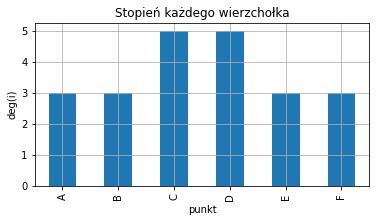

In [52]:
deg_df = pd.DataFrame({
    "punkt": labels,
    "stopień": degrees
})

display(deg_df)

deg_df.plot(
    x="punkt",
    y="stopień",
    kind="bar",
    legend=False,
    figsize=(6,3)
)

plt.title("Stopień każdego wierzchołka")
plt.ylabel("deg(i)")
plt.show()

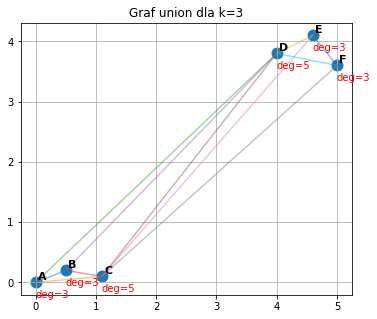

In [53]:
fig, ax = plt.subplots(figsize=(6,5))

plot_graph(X, labels, A_demo, title=f"Graf union dla k={k}", ax=ax)

for i, lab in enumerate(labels):
    ax.text(
        X[i,0],
        X[i,1]-0.25,
        f"deg={degrees[i]}",
        color="red",
        fontsize=10
    )

plt.show()

### Co mierzy stopień?

Stopień jest najprostszą lokalną miarą geometrii grafu.

Później spotkamy bardziej zaawansowane wielkości:

- współczynnik klasteryzacji,
- centralność,
- długości ścieżek,
- wymiar lokalny,
- krzywiznę dyskretną.

Wszystkie one opisują strukturę grafu,
ale stopień jest najprostszym punktem wyjścia.


### Minićwiczenie 9 — własności grafu

Przed uruchomieniem komórki spróbuj odpowiedzieć:

1. Który punkt ma największy stopień?
2. Czy wszystkie punkty mają tyle samo sąsiadów?
3. Ile składowych spójnych ma graf?


<details>
<summary><strong>Rozwiązanie minićwiczenia 9</strong></summary>
    
- Stopień wierzchołka mówi, z iloma sąsiadami jest połączony punkt.
- Punkty położone centralnie w lokalnej grupie często mają większy stopień niż punkty brzegowe.
- Liczba składowych spójnych mówi, na ile niezależnych części rozpada się graf.

W naszych danych szczególnie interesujące jest to, kiedy dwie grupy:

$$
\{A,B,C\}
$$

oraz

$$
\{D,E,F\}
$$

pozostają rozdzielone, a kiedy zostają połączone przez wzrost parametru $k$ lub $\varepsilon$.

</details>

## 8. Co zapamiętać?

- Macierz odległości mówi **jak daleko** są punkty.
- Sama macierz odległości nie jest jeszcze grafem.
- Macierz $\varepsilon$-sąsiedztwa mówi: **czy odległość mieści się w promieniu**.
- Macierz $k$NN mówi: **czy punkt jest wśród $k$ najbliższych sąsiadów**.
- Kierunkowa macierz $k$NN ma w każdym wierszu dokładnie $k$ jedynek.
- Relacja $k$NN nie musi być symetryczna.
- Symetryzacja `union/OR` może dodać dużo połączeń.
- Symetryzacja `mutual/AND` jest bardziej konserwatywna.
- Zbyt duże $k$ potrafi sztucznie połączyć oddzielne grupy.

To jest dokładnie fundament pod **UMAP**, **DBSCAN**, **KNN** i dalsze metody grafowe.
